# Notebook C — Hétérogénéité cellulaire [FACULTATIF]

**Notebook C — Stage de lycée · Laboratoire de microbiologie quantitative  (version stagiaire)**

Ce notebook est la suite facultative du **Notebook B** (Expression génique et régulation).
Il explore deux questions liées :
1. **§C1 — Bistabilité** : pourquoi le TMG produit-il une distribution bimodale de fluorescence ?
2. **§C2 — Analyse ImageJ** : comment quantifier cette hétérogénéité à partir des images de microscopie ?

---

> **Prérequis** : avoir complété §B3 du Notebook B.
> **Environnement** : [Google Colab](https://colab.research.google.com)
> **Durée estimée** : 1–2 demi-journées

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 12
print("Bibliothèques chargées.")

## Section C1 — Bistabilité LacY / TMG

Le TMG est transporté dans la cellule par la protéine **LacY** — elle-même codée par
l'opéron *lac*. Cela crée une **boucle de rétroaction positive** :

```
Plus de LacY → plus de TMG intracellulaire → promoteur plus actif → plus de LacY
```

Cette boucle peut créer **deux états stables** :
- **OFF** : peu de LacY → peu de TMG intracellulaire → promoteur peu actif
- **ON**  : beaucoup de LacY → beaucoup de TMG → promoteur très actif

À des concentrations **intermédiaires** de TMG, les deux états coexistent.
Deux cellules identiques dans le même milieu peuvent finir dans des états différents
selon leur état initial — c'est la **bistabilité**.

> **Lien avec §A** : dans §A, le bruit stochastique créait de la variabilité.
> Ici, la bistabilité crée une distribution bimodale : même sans bruit,
> deux cellules identiques peuvent diverger.

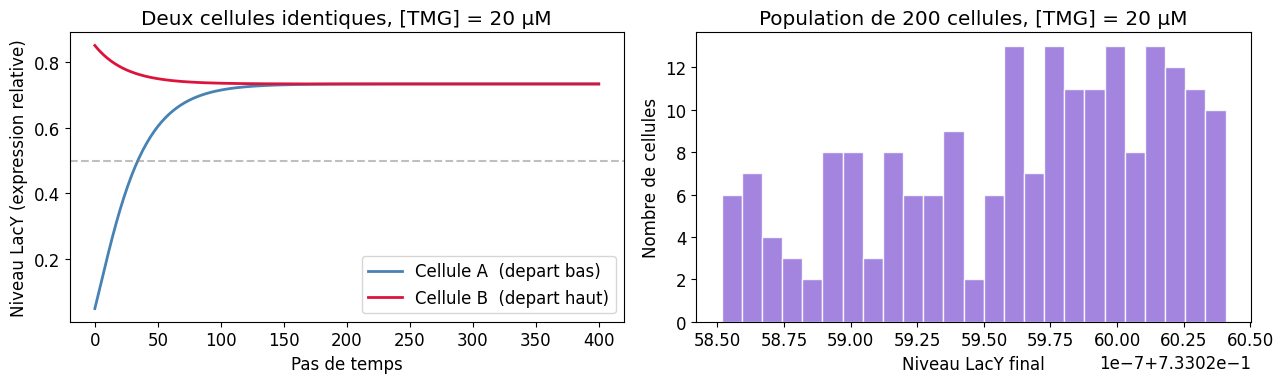

-> Distribution bimodale : chaque cellule converge vers l'un des deux etats stables.

   Essayez tmg_ext = 5, 20, 50, 100 µM.
   A quelle concentration la distribution devient-elle unimodale ?


In [22]:
# Objectif : simuler le système de retro-action LacY/TMG pour deux cellules
# identiques au départ dans des états différents, puis pour une population,
# afin de visualiser la bistabilité.
#
# Paramètres :
#   K_bis   — demi-saturation (µM TMG intracellulaire)
#   gain    — facteur d'amplification du TMG par LacY (retro-action positive)
#   alpha   — vitesse de relaxation de LacY vers sa valeur cible
#   n_t     — nombre de pas de temps
#   tmg_ext — concentration de TMG extracellulaire (µM)
#
# Principe de la simulation, à chaque pas de temps :
#   tmg_eff  = tmg_ext * (1 + gain * lacy)   — le TMG "ressenti" dépend de
#              la quantité de LacY déjà présente (retro-action)
#   p_on_bis = tmg_eff / (K_bis + tmg_eff)   — réponse du promoteur (Hill n=1)
#   lacy     = lacy + alpha * (p_on_bis - lacy)  — relaxation progressive vers
#              p_on_bis, puis bornée entre 0 et 1
#
# Graphique : 2 sous-graphiques côte à côte —
#   Gauche : deux trajectoires (lacy en fonction du pas de temps), pour
#            deux cellules avec des valeurs initiales de lacy différentes
#            (une basse, une haute). Une LISTE traj par cellule, de
#            longueur n_t+1.
#   Droite : histogramme des valeurs FINALES de lacy pour une population de
#            N_pop cellules, chacune partant d'une valeur initiale aléatoire
#            (np.random.uniform(0, 1)). Structure : une LISTE lacy_finales
#            de longueur N_pop.
#
# Afficher avec print() : que représente une distribution bimodale en termes
# de population cellulaire ? Essayer plusieurs valeurs de tmg_ext (5, 20,
# 50, 100 µM) — à quelle concentration la distribution devient-elle
# unimodale ?

## Section C2 — Analyse des données de microscopie (ImageJ)

La microscopie permet de mesurer la fluorescence de **cellules individuelles** et
d'observer directement la distribution dans la population.

**Export depuis ImageJ** :
1. Ouvrir l'image, segmenter les cellules (*Analyze Particles*)
2. *Measure* → exporter le tableau en CSV (une ligne par cellule)
3. Répéter pour chaque concentration de TMG

La colonne utile dans le CSV ImageJ est `Mean` (fluorescence moyenne par cellule).

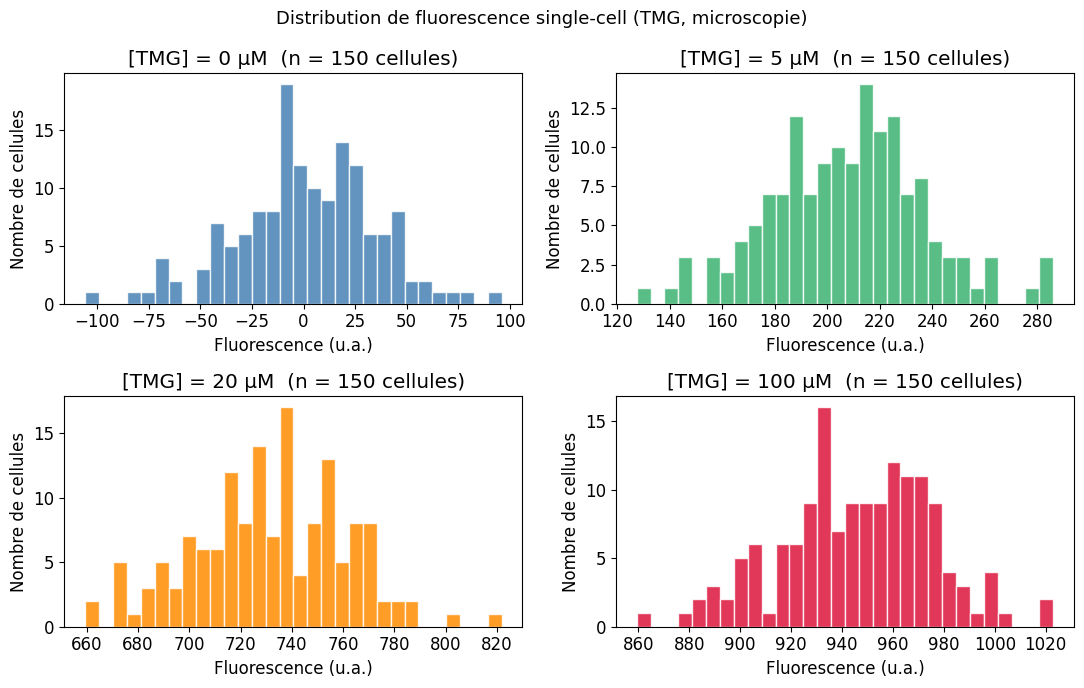

Questions :
  1. A quelle [TMG] voit-on deux pics separes ?
  2. La fraction de cellules ON augmente-t-elle avec [TMG] ?
  3. Ces resultats correspondent-ils aux predictions de §D1 ?


In [23]:
# Objectif : charger (ou simuler) les données de fluorescence single-cell
# obtenues par analyse ImageJ pour plusieurs concentrations de TMG, et
# tracer les histogrammes de distribution.
#
# Données à charger (réelles) :
#   concs_tmg  — LISTE des concentrations de TMG utilisées en microscopie
#                (ex. [0, 5, 20, 100])
#   donnees_ij — DICTIONNAIRE {concentration: DataFrame}, un DataFrame par
#                concentration, chargé depuis un fichier CSV exporté d'ImageJ
#                (pd.read_csv). La colonne 'Mean' contient la fluorescence
#                moyenne de chaque cellule détectée.
#
# Si les données réelles ne sont pas encore disponibles, utiliser des
# données synthétiques de structure équivalente : pour chaque concentration,
# un TABLEAU numpy de valeurs de fluorescence (une valeur par cellule).
#
# Graphique : grille de sous-graphiques (plt.subplots(2, 2, ...)), un
# histogramme par concentration de concs_tmg (plt.hist).
#
# Afficher avec print() vos réponses : à quelle concentration de TMG voit-on
# deux pics séparés (distribution bimodale) ? La fraction de cellules "ON"
# augmente-t-elle avec [TMG] ? Ces résultats sont-ils cohérents avec les
# prédictions de la simulation du §C1 ?

---
## Pour aller plus loin

1. **Distribution bimodale et bruit** : comment distinguer expérimentalement
   bistabilité (deux états stables) et bruit stochastique élevé ?
   *Indice* : refaire l'expérience avec deux inducteurs différents (IPTG vs TMG)
   et comparer les distributions.

2. **Connexion avec Elowitz 2002** : l'analyse single-cell que vous avez faite
   est proche de l'expérience fondatrice sur le bruit d'expression.
   Dans ce papier, deux gènes rapporteurs identiques dans la même cellule montraient
   des niveaux différents — preuve directe du bruit *intrinsèque*.

3. **Quantifier la bimodalité** : pouvez-vous mesurer la fraction de cellules ON
   pour chaque concentration de TMG et tracer cette fraction en fonction de [TMG] ?
   Que devrait prédire le modèle de bistabilité de §C1 ?